<a href="https://colab.research.google.com/github/GaboGolCs/PainPredict-Neuro/blob/feat%2Fg3-actividad3-desbalance/actividad_5A_eeg_desbalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 3: Análisis de Desbalance de Clases en EEG (Escala NRS) - Grupo 3

> Regla del equipo: Cada integrante debe trabajar exclusivamente en el bloque que le corresponde. No alterar el código de los demás.

## Bloque 1: Procesamiento de Datos (Asignado a: Juan)

1. Importar librerías.
2. Cargar 'dataset_features_eeg.csv'.
3. Calcular porcentajes con value_counts(normalize=True) * 100.

In [ ]:
# Importamos librerías necesarias para el desarrollo de la actividad
import pandas as pd
from google.colab import drive

# Conectamos Colab con entorno de Google Drive para usar los archivos
drive.mount('/content/drive')

# Cargamos archivo CSV (dataset con datos crudos) desde la carpeta compartida DATA_GPI
ruta_real = '/content/drive/Shareddrives/DATA_GPI/Nuestros Datasets/dataset_features_eeg.csv'
df = pd.read_csv(ruta_real)

# Identificamos y seleccionamos columna que contiene los niveles de dolor en el dataset
columna_clases = 'nrs_score'

# Obtenemos y contamos los datos de cada nivel de dolor en el dataset, luego los multiplicamos por 100
# Resultado: Obtención de porcentajes para saber la distribución real de las clases de dolor en el dataset
porcentajes = df[columna_clases].value_counts(normalize=True) * 100

# Mostramos resultados ordenados y limpios para el informe del grupo
print("\n--- Porcentajes de las 4 clases de dolor ---")
for clase, porcentaje in porcentajes.sort_index().items():
    print(f"Clase (NRS) {clase}: {porcentaje:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Porcentajes de las 4 clases de dolor ---
Clase (NRS) 32: 35.08%
Clase (NRS) 33: 29.41%
Clase (NRS) 34: 19.92%
Clase (NRS) 35: 15.59%


## Bloque 2: Visualización Gráfica y Exportación (Asignado a: Franco)

1. Crear Countplot de seaborn.
2. Obligatorio exportar la imagen usando plt.savefig('desbalance_eeg.png', dpi=300, bbox_inches='tight') antes del show().

Iniciando generación de gráfico Countplot...
Códigos mapeados exitosamente a la escala NRS (2, 4, 6, 8).
¡Imagen exportada exitosamente como 'desbalance_eeg.png'!


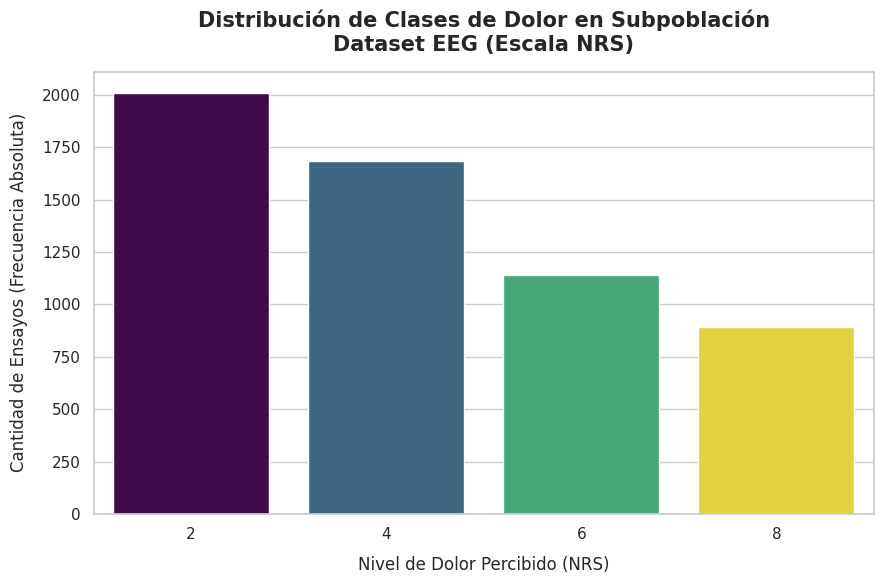

In [ ]:
# Importamos librerías necesarias para la construcción del gráfico
import matplotlib.pyplot as plt
import seaborn as sns

print("Iniciando generación de gráfico Countplot...")

# Mapeo de los códigos crudos a la escala NRS real (2, 4, 6, 8) solicitada
mapeo_nrs = {32: 2, 33: 4, 34: 6, 35: 8}

# Verificamos si los valores 32-35 existen antes de mapear (Esto evita errores si se ejecuta la celda dos o más veces)
if df['nrs_score'].isin([32]).any():
    df['nrs_score'] = df['nrs_score'].map(mapeo_nrs)
    print("Códigos mapeados exitosamente a la escala NRS (2, 4, 6, 8).")

# Configuración de estilo gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# Construcción de gráfico de barras (Countplot) de "Distribución de clases de dolor"
# haciendo uso de la etiqueta de dolor "nrs_score" (variable x)
grafico = sns.countplot(
    x='nrs_score',
    data=df,
    hue='nrs_score',
    palette='viridis',
    legend=False
)

# Títulos y etiquetas formales para el gráfico
plt.title('Distribución de Clases de Dolor en Subpoblación\nDataset EEG (Escala NRS)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Nivel de Dolor Percibido (NRS)', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Ensayos (Frecuencia Absoluta)', fontsize=12, labelpad=10)

# Ajuste de los ticks para obtener valores legibles
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Exportación en Alta Resolución con los estánderes solicitados (dpi=300 y bbox_inches='tight')
ruta_imagen = 'desbalance_eeg.png'
plt.savefig(ruta_imagen, dpi=300, bbox_inches='tight')
print(f"¡Imagen exportada exitosamente como '{ruta_imagen}'!")

# Despliegue del gráfico
plt.tight_layout()
plt.show()